# Explore here

Traje todas las librerias para tener un orden en el book

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

descargamos el data de el link, y lo pasamos a raw

In [150]:


df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv")
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Para mayor comodidad descargamos los datos a raw para que sea mas facil el uso

In [151]:
df.to_csv("../data/raw/data_crudos.csv", index=False)

ya guardados los descargamos de la carpeta de raw en data

In [152]:
df = pd.read_csv("../data/raw/data_crudos.csv")

empezamos a revisar mas los datos en que de dividen si numericas o categoricas

In [153]:
df. info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Indagamos un poco mas en la informacion para conocer mas sobre los datos

In [154]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Aun que con el info nos dijo que no habian nulls usamos el codigo por si hay algun dato que se excluyera

In [155]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Creamos una histplot para ver los datos mas a profundidad, en este caso podemos ver que en promedio la gente no paga mucho por el seguro medico pero hay una pequeña fraccion que si revisemos el por que...

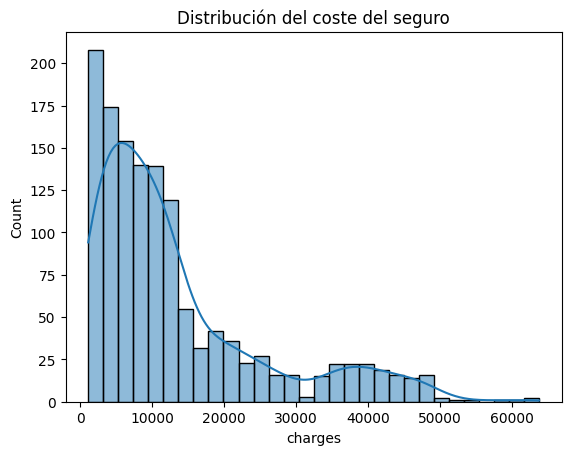

In [156]:
sns.histplot(df["charges"], kde=True)
plt.title("Distribución del coste del seguro")
plt.show()

Para no dejar información fuera generamos que los datos categoricos se conviertan en numeros para saber si en ellos hay una correlacion

In [159]:
df = pd.get_dummies(df, drop_first=True)

Creo una heatmap para ver las correlaciones mas visibles de todas las columnas-

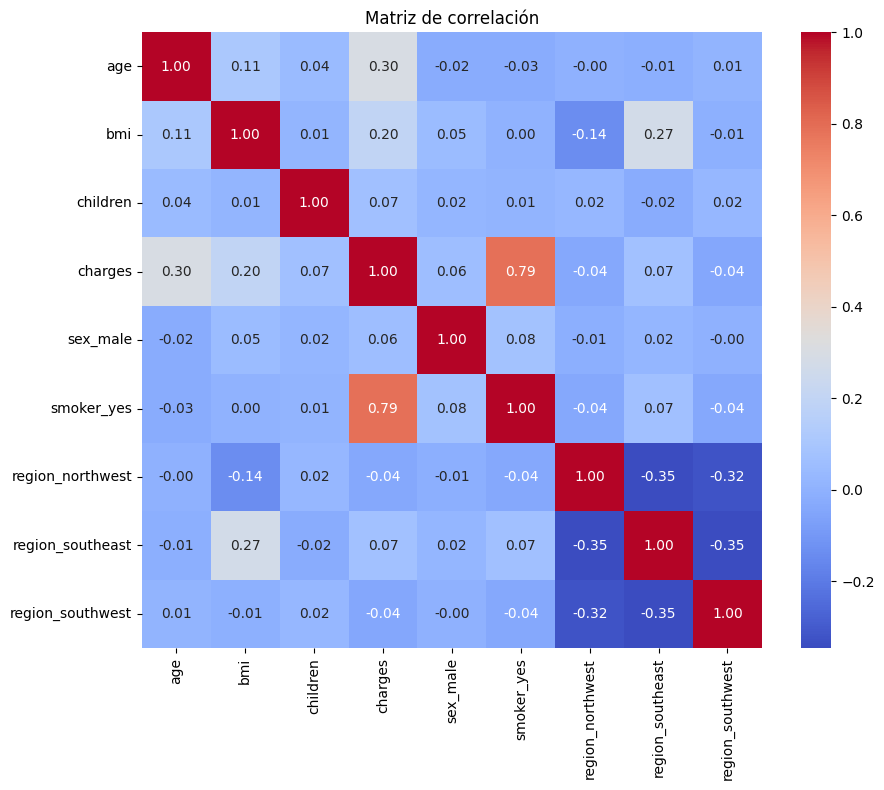

In [160]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriz de correlación")
plt.show()

Podemos definir que la mayor correlacion es si eres un fumador, dando un caso .80

Separemos las columnas en x como todas excluyendo a charges ya que es nuestra variable meta

In [161]:
X = df.drop("charges", axis=1)
y = df["charges"]

Empezamos a diseñar el train test, con la informacion general para que si se usa en otro proyecto todos sepan los datos con los que esta corriendo el programa

In [162]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Empezamos a entrenar el modelo

In [163]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


y a base del entrenamiento, podemos definir el r2 que en este caso es de .78 por lo que es un buen modelo.

In [164]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R2:", r2)

R2: 0.7835929767120724
